**Install dependencies**

In [1]:
!pip install bert-score
!pip install sacrebleu
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.7 MB/s eta 0:00:00


**Import Libraries**

In [2]:
import os
import time
import math
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from nltk.translate.bleu_score import corpus_bleu

from bert_score import score as bert_score

warnings.filterwarnings("ignore")

**Check GPU**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


**Set Random Seeds**

In [4]:
SEED = 42

random.seed(SEED) #controlling python's random generator
np.random.seed(SEED) #controlling randomness in numpy

torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

**Upload Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving dev_en_1000.csv to dev_en_1000.csv
Saving dev_sa_1000.csv to dev_sa_1000.csv
Saving test_en_1000.csv to test_en_1000.csv
Saving test_sa_1000.csv to test_sa_1000.csv
Saving train_en_10000.csv to train_en_10000.csv
Saving train_sa_10000.csv to train_sa_10000.csv


**Exploratory Data Analysis (EDA)**

In [6]:
#Read the CSV files
train_sa = pd.read_csv("train_sa_10000.csv")
train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")
dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")
test_en = pd.read_csv("test_en_1000.csv")

In [7]:
#Display the first few rows
print("Training Sanskrit")
display(train_sa.head())

print("\nTraining English")
display(train_en.head())

print("\nDevelopment Sanskrit")
display(dev_sa.head())

print("\nDevelopment English")
display(dev_en.head())

Training Sanskrit


,Source_id,Sentence_sa
0,1,"""Ctrl, S नुत्वा रक्षन्तु।"""
1,2,गुरुः छात्रान् एकवारं पाठयति ।
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत..."



Training English


,Source_id,Sentence_en
0,1,"Save it with Ctrl, S."
1,2,Teacher will teach the students only once.
2,3,"To recreate this animation, I have to take two..."
3,4,I will choose Colors options by clicking on it.
4,5,"""See the example here - one mountain, four vil..."



Development Sanskrit


,Source_id,Sentence_sa
0,1,ते वीराः ।
1,2,'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां क...
2,3,ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर...
3,4,एते तिथी ।
4,5,"""बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्..."



Development English


,Source_id,Sentence_en
0,1,Those are brave men.
1,2,Infinite loop can cause the system to become ...
2,3,"""And they spit upon him, and took the reed, an..."
3,4,These two are dates.
4,5,"""And when there had been much disputing, Peter..."


In [8]:
#Check dataset sizes
print("Train Sanskrit :", train_sa.shape)
print("Train English  :", train_en.shape)

print("Dev Sanskrit   :", dev_sa.shape)
print("Dev English    :", dev_en.shape)

print("Test Sanskrit  :", test_sa.shape)
print("Test English   :", test_en.shape)

Train Sanskrit : (10000, 2)
Train English  : (10000, 2)
Dev Sanskrit   : (1000, 2)
Dev English    : (1000, 2)
Test Sanskrit  : (1000, 2)
Test English   : (1000, 2)


In [9]:
#Merge the parallel sentences
train = pd.merge(train_sa, train_en, on="Source_id")
dev = pd.merge(dev_sa, dev_en, on="Source_id")
test = pd.merge(test_sa, test_en, on="Source_id")

In [10]:
#Check the merged data
display(train.head())

print(train.columns)

,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


Index(['Source_id', 'Sentence_sa', 'Sentence_en'], dtype='object')


In [11]:
display(test.head())

print(test.columns)

,Source_id,Sentence_sa,Sentence_en
0,1,एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि...,Eclipse also helps the programmer to find out ...
1,2,विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्...,"""We having the same spirit of faith, according..."
2,3,"तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं...",Then it will automatically begin searching for...
3,4,"सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्...",The iterator will be set to each of the indice...
4,5,अपरं द्वितीयमुद्रायां तेन मोचितायां द्वितीयस्य...,"""And when he had opened the second seal, I hea..."


Index(['Source_id', 'Sentence_sa', 'Sentence_en'], dtype='object')


**Check for missing values**

In [12]:
print(train.isnull().sum())
print(dev.isnull().sum())
print(test.isnull().sum())

Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64
Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64
Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64


**Sentence length analysis**

In [13]:
train["sa_length"] = train["Sentence_sa"].apply(lambda x: len(str(x).split()))
train["en_length"] = train["Sentence_en"].apply(lambda x: len(str(x).split()))

**Basic statistics**

In [14]:
print("Sanskrit Sentence Length Statistics")
print(train["sa_length"].describe())

print("\nEnglish Sentence Length Statistics")
print(train["en_length"].describe())

Sanskrit Sentence Length Statistics
count    10000.000000
mean         9.667800
std          5.494112
min          1.000000
25%          5.000000
50%          9.000000
75%         13.000000
max         55.000000
Name: sa_length, dtype: float64

English Sentence Length Statistics
count    10000.000000
mean        12.643900
std          8.015954
min          1.000000
25%          7.000000
50%         11.000000
75%         16.000000
max        116.000000
Name: en_length, dtype: float64


**Plot sentence length distribution**

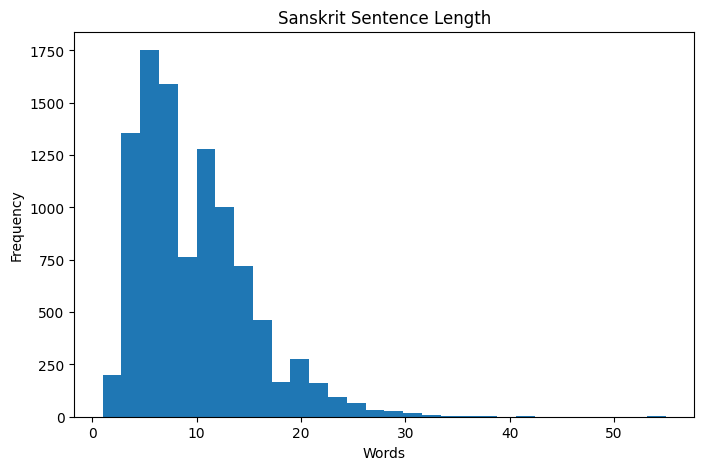

In [15]:
plt.figure(figsize=(8,5))
plt.hist(train["sa_length"], bins=30)
plt.title("Sanskrit Sentence Length")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

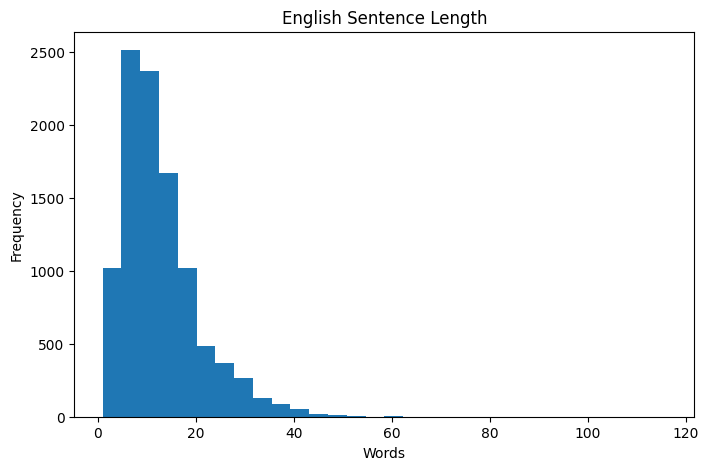

In [16]:
#for english
plt.figure(figsize=(8,5))
plt.hist(train["en_length"], bins=30)
plt.title("English Sentence Length")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [17]:
MAX_SRC_LEN = 30
MAX_TRG_LEN = 40

**Text Preprocessing**

In [18]:
#Define Special Tokens
PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

In [19]:

#Build a Vocabulary Class
from collections import Counter

class Vocabulary:

    def __init__(self, min_freq=2):

        self.min_freq = min_freq

        self.word2idx = {
            PAD_TOKEN: 0,
            SOS_TOKEN: 1,
            EOS_TOKEN: 2,
            UNK_TOKEN: 3
        }

        self.idx2word = {
            0: PAD_TOKEN,
            1: SOS_TOKEN,
            2: EOS_TOKEN,
            3: UNK_TOKEN
        }

        self.word_freq = Counter()

    def build_vocab(self, sentences):

        for sentence in sentences:
            words = str(sentence).split()
            self.word_freq.update(words)

        for word, freq in self.word_freq.items():

            if freq >= self.min_freq:

                if word not in self.word2idx:

                    idx = len(self.word2idx)

                    self.word2idx[word] = idx
                    self.idx2word[idx] = word

    def numericalize(self, sentence):

        words = str(sentence).split()

        return [
            self.word2idx.get(word, self.word2idx[UNK_TOKEN])
            for word in words
        ]

    def decode(self, indices):

      words = []

      for idx in indices:

        idx = int(idx)

        # Skip PAD and SOS
        if idx == self.word2idx[PAD_TOKEN]:
            continue

        if idx == self.word2idx[SOS_TOKEN]:
            continue

        # Stop at EOS
        if idx == self.word2idx[EOS_TOKEN]:
            break

        words.append(
            self.idx2word.get(idx, UNK_TOKEN)
        )

        return words

#testing

**Build Sanskrit and English Vocabularies**

In [20]:
src_vocab = Vocabulary(min_freq=2)
src_vocab.build_vocab(train["Sentence_sa"])

trg_vocab = Vocabulary(min_freq=2)
trg_vocab.build_vocab(train["Sentence_en"])

print("Sanskrit Vocabulary:", len(src_vocab.word2idx))
print("English Vocabulary :", len(trg_vocab.word2idx))

Sanskrit Vocabulary: 8485
English Vocabulary : 7649


**TranslationDataset and DataLoader**

In [21]:
from torch.utils.data import Dataset, DataLoader
import torch

# Maximum sequence lengths
MAX_SRC_LEN = 30
MAX_TRG_LEN = 40


class TranslationDataset(Dataset):

    def __init__(self, dataframe, src_vocab, trg_vocab,
                 max_src_len=MAX_SRC_LEN,
                 max_trg_len=MAX_TRG_LEN):

        self.data = dataframe
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_src_len = max_src_len
        self.max_trg_len = max_trg_len

    def __len__(self):
        return len(self.data)

    def pad_sequence(self, sequence, max_len):

        if len(sequence) < max_len:
            sequence = sequence + [self.src_vocab.word2idx[PAD_TOKEN]] * (max_len - len(sequence))
        else:
            sequence = sequence[:max_len]

        return sequence

    def pad_target(self, sequence, max_len):

        if len(sequence) < max_len:
            sequence = sequence + [self.trg_vocab.word2idx[PAD_TOKEN]] * (max_len - len(sequence))
        else:
            sequence = sequence[:max_len]

        return sequence

    def __getitem__(self, idx):

        src_sentence = self.data.iloc[idx]["Sentence_sa"]
        trg_sentence = self.data.iloc[idx]["Sentence_en"]

        # Convert words to indices
        src_indices = self.src_vocab.numericalize(src_sentence)

        trg_indices = self.trg_vocab.numericalize(trg_sentence)

        # Add SOS and EOS tokens
        trg_indices = (
            [self.trg_vocab.word2idx[SOS_TOKEN]]
            + trg_indices
            + [self.trg_vocab.word2idx[EOS_TOKEN]]
        )

        # Pad sequences
        src_indices = self.pad_sequence(src_indices, self.max_src_len)

        trg_indices = self.pad_target(trg_indices, self.max_trg_len)

        return (
            torch.tensor(src_indices, dtype=torch.long),
            torch.tensor(trg_indices, dtype=torch.long)
        )


# Create Dataset objects

train_dataset = TranslationDataset(train, src_vocab, trg_vocab)

dev_dataset = TranslationDataset(dev, src_vocab, trg_vocab)

test_dataset = TranslationDataset(test, src_vocab, trg_vocab)


# Create DataLoaders

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets and DataLoaders created successfully.")

Datasets and DataLoaders created successfully.


**Verify the Dataset**

In [22]:
print("Training Samples :", len(train_dataset))
print("Development Samples :", len(dev_dataset))
print("Test Samples :", len(test_dataset))

Training Samples : 10000
Development Samples : 1000
Test Samples : 1000


**Inspect One Sample**

In [23]:
src_tensor, trg_tensor = train_dataset[0]

print("Source Tensor Shape :", src_tensor.shape)
print("Target Tensor Shape :", trg_tensor.shape)

print("\nSource Tensor")
print(src_tensor)

print("\nTarget Tensor")
print(trg_tensor)

Source Tensor Shape : torch.Size([30])
Target Tensor Shape : torch.Size([40])

Source Tensor
tensor([3, 4, 5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0])

Target Tensor
tensor([1, 4, 5, 6, 7, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


**Inspect One Batch**

In [24]:
src_batch, trg_batch = next(iter(train_loader))

print("Source Batch Shape :", src_batch.shape)
print("Target Batch Shape :", trg_batch.shape)

Source Batch Shape : torch.Size([64, 30])
Target Batch Shape : torch.Size([64, 40])


**Encoder**

In [25]:
class Encoder(nn.Module):

    def __init__(self,
                 input_dim,
                 emb_dim,
                 hidden_dim,
                 num_layers,
                 dropout):

        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=input_dim,
            embedding_dim=emb_dim,
            padding_idx=0
        )

        # Bidirectional LSTM
        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=True,
            batch_first=True
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):

        # src shape
        # (batch_size, src_len)

        embedded = self.dropout(
            self.embedding(src)
        )

        # embedded shape
        # (batch_size, src_len, emb_dim)

        outputs, (hidden, cell) = self.rnn(embedded)

        # outputs
        # (batch_size, src_len, hidden_dim*2)

        # hidden
        # (num_layers*2, batch_size, hidden_dim)

        # cell
        # (num_layers*2, batch_size, hidden_dim)

        return outputs, hidden, cell

**Hyperparameters**

In [26]:
INPUT_DIM = len(src_vocab.word2idx)

EMB_DIM = 256

HIDDEN_DIM = 256

NUM_LAYERS = 2

DROPOUT = 0.3

**Create Encoder**

In [27]:
encoder = Encoder(
    input_dim=INPUT_DIM,
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(encoder)

Encoder(
  (embedding): Embedding(8485, 256, padding_idx=0)
  (rnn): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


**Test the Encoder**

In [28]:
src_batch = src_batch.to(device)

encoder_outputs, hidden, cell = encoder(src_batch)

print("Encoder Outputs Shape :", encoder_outputs.shape)
print("Hidden Shape :", hidden.shape)
print("Cell Shape :", cell.shape)

Encoder Outputs Shape : torch.Size([64, 30, 512])
Hidden Shape : torch.Size([4, 64, 256])
Cell Shape : torch.Size([4, 64, 256])


**Attention**

In [29]:
class Attention(nn.Module):

    def __init__(self,
                 encoder_hidden_dim,
                 decoder_hidden_dim):

        super().__init__()

        self.attn = nn.Linear(
            encoder_hidden_dim * 2 + decoder_hidden_dim,
            decoder_hidden_dim
        )

        self.v = nn.Linear(
            decoder_hidden_dim,
            1,
            bias=False
        )

    def forward(self,
                hidden,
                encoder_outputs):

        # hidden
        # (batch_size, decoder_hidden_dim)

        # encoder_outputs
        # (batch_size, src_len, encoder_hidden_dim*2)

        batch_size = encoder_outputs.shape[0]

        src_len = encoder_outputs.shape[1]

        # Repeat decoder hidden state for every source word

        hidden = hidden.unsqueeze(1).repeat(
            1,
            src_len,
            1
        )

        # hidden
        # (batch_size, src_len, decoder_hidden_dim)

        energy = torch.tanh(

            self.attn(

                torch.cat(

                    (
                        hidden,
                        encoder_outputs
                    ),

                    dim=2

                )

            )

        )

        # energy
        # (batch_size, src_len, decoder_hidden_dim)

        attention = self.v(energy).squeeze(2)

        # attention
        # (batch_size, src_len)

        return torch.softmax(
            attention,
            dim=1
        )

**Create Attention**

In [30]:
attention = Attention(
    encoder_hidden_dim=HIDDEN_DIM,
    decoder_hidden_dim=HIDDEN_DIM
).to(device)

print(attention)

Attention(
  (attn): Linear(in_features=768, out_features=256, bias=True)
  (v): Linear(in_features=256, out_features=1, bias=False)
)


**Test Attention**

In [31]:
decoder_hidden = hidden[-2]

attention_weights = attention(
    decoder_hidden,
    encoder_outputs
)

print(attention_weights.shape)

torch.Size([64, 30])


**Decoder**

In [32]:
class Decoder(nn.Module):

    def __init__(self,
                 output_dim,
                 emb_dim,
                 encoder_hidden_dim,
                 decoder_hidden_dim,
                 num_layers,
                 dropout,
                 attention):

        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        # Embedding layer
        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=0
        )

        # LSTM
        self.rnn = nn.LSTM(
            input_size=emb_dim + encoder_hidden_dim * 2,
            hidden_size=decoder_hidden_dim,
            num_layers=1,
            batch_first=True
        )

        # Fully connected layer
        self.fc_out = nn.Linear(
            emb_dim +
            encoder_hidden_dim * 2 +
            decoder_hidden_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self,
                input,
                hidden,
                cell,
                encoder_outputs):

        # input
        # (batch_size)

        input = input.unsqueeze(1)

        # (batch_size,1)

        embedded = self.dropout(
            self.embedding(input)
        )

        # (batch_size,1,emb_dim)

        attention_weights = self.attention(
            hidden,
            encoder_outputs
        )

        # (batch_size,src_len)

        attention_weights = attention_weights.unsqueeze(1)

        # (batch_size,1,src_len)

        context = torch.bmm(
            attention_weights,
            encoder_outputs
        )

        # (batch_size,1,512)

        rnn_input = torch.cat(
            (
                embedded,
                context
            ),
            dim=2
        )

        # (batch_size,1,emb_dim+512)

        output, (hidden, cell) = self.rnn(
            rnn_input,
            (
                hidden.unsqueeze(0),
                cell.unsqueeze(0)
            )
        )

        # output
        # (batch_size,1,256)

        output = output.squeeze(1)
        context = context.squeeze(1)
        embedded = embedded.squeeze(1)

        prediction = self.fc_out(
            torch.cat(
                (
                    output,
                    context,
                    embedded
                ),
                dim=1
            )
        )

        return prediction, hidden.squeeze(0), cell.squeeze(0)

**Create Decoder**

In [33]:
OUTPUT_DIM = len(trg_vocab.word2idx)

decoder = Decoder(
    output_dim=OUTPUT_DIM,
    emb_dim=EMB_DIM,
    encoder_hidden_dim=HIDDEN_DIM,
    decoder_hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    attention=attention
).to(device)

print(decoder)

Decoder(
  (attention): Attention(
    (attn): Linear(in_features=768, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (embedding): Embedding(7649, 256, padding_idx=0)
  (rnn): LSTM(768, 256, batch_first=True)
  (fc_out): Linear(in_features=1024, out_features=7649, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


**Test Decoder**

In [34]:
decoder_hidden = hidden[-2]
decoder_cell = cell[-2]

In [35]:
decoder_input = torch.full(
    (BATCH_SIZE,),
    trg_vocab.word2idx[SOS_TOKEN],
    dtype=torch.long,
    device=device
)

In [36]:
prediction, decoder_hidden, decoder_cell = decoder(
    decoder_input,
    decoder_hidden,
    decoder_cell,
    encoder_outputs
)

print("Prediction Shape :", prediction.shape)
print("Hidden Shape :", decoder_hidden.shape)
print("Cell Shape :", decoder_cell.shape)

Prediction Shape : torch.Size([64, 7649])
Hidden Shape : torch.Size([64, 256])
Cell Shape : torch.Size([64, 256])


**Seq2Seq Model**

In [37]:
class Seq2Seq(nn.Module):

    def __init__(self,
                 encoder,
                 decoder,
                 device):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self,
                src,
                trg,
                teacher_forcing_ratio=0.5):

        batch_size = src.shape[0]

        trg_len = trg.shape[1]

        trg_vocab_size = self.decoder.output_dim

        # Store decoder outputs
        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size
        ).to(self.device)

        # Encoder
        encoder_outputs, hidden, cell = self.encoder(src)

        # Initial decoder hidden/cell
        hidden = hidden[-2]
        cell = cell[-2]

        # First decoder input = <SOS>
        input = trg[:, 0]

        # Decode one word at a time
        for t in range(1, trg_len):

            output, hidden, cell = self.decoder(
                input,
                hidden,
                cell,
                encoder_outputs
            )

            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio

            top1 = output.argmax(1)

            input = trg[:, t] if teacher_force else top1

        return outputs

**Create the Model**

In [38]:
model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8485, 256, padding_idx=0)
    (rnn): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn): Linear(in_features=768, out_features=256, bias=True)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(7649, 256, padding_idx=0)
    (rnn): LSTM(768, 256, batch_first=True)
    (fc_out): Linear(in_features=1024, out_features=7649, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


**Test the Complete Model**

In [39]:
src_batch = src_batch.to(device)
trg_batch = trg_batch.to(device)

outputs = model(
    src_batch,
    trg_batch
)

print(outputs.shape)

torch.Size([64, 40, 7649])


**Define the Loss Function**

In [40]:
criterion = nn.CrossEntropyLoss(
    ignore_index=trg_vocab.word2idx[PAD_TOKEN],
    label_smoothing=0.1
)

**Optimizer**

In [41]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

**Scheduler**

In [42]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

**Gradient Clipping**

In [43]:
CLIP = 1

**Training Function**

In [44]:
def train_epoch(model,
          dataloader,
          optimizer,
          criterion,
          clip):

    model.train()

    epoch_loss = 0

    for src, trg in dataloader:

        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(
            src,
            trg
        )

        output_dim = output.shape[-1]

        output = output[:,1:].reshape(-1, output_dim)

        trg = trg[:,1:].reshape(-1)

        loss = criterion(
            output,
            trg
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

**Validation Function**

In [45]:
def evaluate(model,
             dataloader,
             criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, trg in dataloader:

            src = src.to(device)
            trg = trg.to(device)

            output = model(
                src,
                trg,
                teacher_forcing_ratio=0
            )

            output_dim = output.shape[-1]

            output = output[:,1:].reshape(-1, output_dim)

            trg = trg[:,1:].reshape(-1)

            loss = criterion(
                output,
                trg
            )

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

**EarlyStopping class**

In [46]:
class EarlyStopping:

    def __init__(self, patience=4, delta=0):

        self.patience = patience
        self.delta = delta

        self.best_loss = float("inf")

        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.delta:

            self.best_loss = val_loss

            self.counter = 0

            return False

        else:

            self.counter += 1

            print(f"EarlyStopping Counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:

                self.early_stop = True

                return True

            return False

**Initialize Early stopping**

In [47]:
early_stopping = EarlyStopping(
    patience=4
)

**Training Loop**

In [48]:
N_EPOCHS = 15

best_valid_loss = float("inf")

train_losses = []
valid_losses = []

for epoch in range(N_EPOCHS):

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        CLIP
    )

    valid_loss = evaluate(
        model,
        dev_loader,
        criterion
    )
    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    if early_stopping(valid_loss):

      print()

      print("Early Stopping Triggered")

      break

    print(f"Epoch {epoch+1}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Learning Rate : {optimizer.param_groups[0]['lr']:.6f}")

Epoch 1
Train Loss : 6.5472
Valid Loss : 6.1202
Learning Rate : 0.001000
Epoch 2
Train Loss : 6.0275
Valid Loss : 5.9836
Learning Rate : 0.001000
Epoch 3
Train Loss : 5.7847
Valid Loss : 5.8986
Learning Rate : 0.001000
Epoch 4
Train Loss : 5.5493
Valid Loss : 5.8670
Learning Rate : 0.001000
Epoch 5
Train Loss : 5.3505
Valid Loss : 5.7873
Learning Rate : 0.001000
Epoch 6
Train Loss : 5.1697
Valid Loss : 5.7734
Learning Rate : 0.001000
Epoch 7
Train Loss : 4.9533
Valid Loss : 5.7696
Learning Rate : 0.001000
Epoch 8
Train Loss : 4.7637
Valid Loss : 5.7532
Learning Rate : 0.001000
EarlyStopping Counter: 1/4
Epoch 9
Train Loss : 4.5828
Valid Loss : 5.7685
Learning Rate : 0.001000
EarlyStopping Counter: 2/4
Epoch 10
Train Loss : 4.3936
Valid Loss : 5.8175
Learning Rate : 0.001000
EarlyStopping Counter: 3/4
Epoch 11
Train Loss : 4.2220
Valid Loss : 5.8096
Learning Rate : 0.000500
EarlyStopping Counter: 4/4

Early Stopping Triggered


**Load the Best Model**

In [49]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


**Plot Training and Validation Loss**

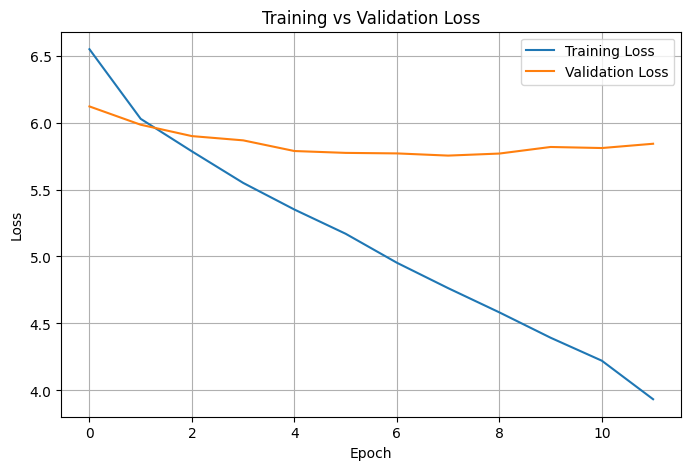

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [51]:
plt.savefig("loss_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

**Verify the Loaded Model**

In [52]:
src_batch, trg_batch = next(iter(dev_loader))

src_batch = src_batch.to(device)
trg_batch = trg_batch.to(device)

with torch.no_grad():

    outputs = model(
        src_batch,
        trg_batch,
        teacher_forcing_ratio=0
    )

print(outputs.shape)

torch.Size([64, 40, 7649])


Adding a decode method

In [53]:
def decode(self, indices):

    words = []

    for idx in indices:

        idx = int(idx)

        if idx == self.word2idx[PAD_TOKEN]:
            continue

        if idx == self.word2idx[SOS_TOKEN]:
            continue

        if idx == self.word2idx[EOS_TOKEN]:
            break

        words.append(self.idx2word.get(idx, UNK_TOKEN))

    return words


Vocabulary.decode = decode

**Test the decode method**

In [54]:
sample_target = trg_batch[0].cpu().numpy()

decoded = trg_vocab.decode(sample_target)

print(decoded)

['Those', 'are', 'brave', 'men.']


**Greedy Translation Function**

In [55]:
def translate_sentence(model,
                       sentence,
                       src_vocab,
                       trg_vocab,
                       device,
                       max_len=40):

    model.eval()

    # ----------------------------
    # Convert sentence to indices
    # ----------------------------

    tokens = sentence.split()

    src_indices = [
        src_vocab.word2idx.get(
            token,
            src_vocab.word2idx[UNK_TOKEN]
        )
        for token in tokens
    ]

    # Pad / truncate source sentence

    if len(src_indices) < MAX_SRC_LEN:

        src_indices += [
            src_vocab.word2idx[PAD_TOKEN]
        ] * (MAX_SRC_LEN - len(src_indices))

    else:

        src_indices = src_indices[:MAX_SRC_LEN]

    src_tensor = torch.tensor(
        src_indices,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    # Since encoder is Bi-LSTM
    hidden = hidden[-2]
    cell = cell[-2]

    # First decoder input is <SOS>

    input_token = torch.tensor(
        [trg_vocab.word2idx[SOS_TOKEN]],
        device=device
    )

    predicted_indices = []

    for _ in range(max_len):

        with torch.no_grad():

            output, hidden, cell = model.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs
            )

        pred_token = output.argmax(1).item()

        if pred_token == trg_vocab.word2idx[EOS_TOKEN]:
            break

        predicted_indices.append(pred_token)

        input_token = torch.tensor(
            [pred_token],
            device=device
        )

    return trg_vocab.decode(predicted_indices)

**Test on One Sentence**

In [56]:
sample = train.iloc[0]["Sentence_sa"]

print("Sanskrit Sentence:\n")
print(sample)

prediction = translate_sentence(
    model,
    sample,
    src_vocab,
    trg_vocab,
    device
)

print("\nPredicted Translation:\n")
print(" ".join(prediction))

print("\nGround Truth:\n")
print(train.iloc[0]["Sentence_en"])

Sanskrit Sentence:

"Ctrl, S नुत्वा रक्षन्तु।"

Predicted Translation:

Click on the <UNK>

Ground Truth:

Save it with Ctrl, S.


In [57]:
print(type(train))

<class 'pandas.core.frame.DataFrame'>


In [58]:
import random

for i in random.sample(range(len(dev)), 10):

    src = dev.iloc[i]["Sentence_sa"]

    pred = translate_sentence(
        model,
        src,
        src_vocab,
        trg_vocab,
        device
    )

    gt = dev.iloc[i]["Sentence_en"]

    print("="*80)

    print("SOURCE:")
    print(src)

    print()

    print("PREDICTION:")
    print(" ".join(pred))

    print()

    print("GROUND TRUTH:")
    print(gt)

    print()

SOURCE:
अधुना संसूचके टङ्कयतु - "chmod space 751 space example1" Enter  नुदतु

PREDICTION:
Now, type: ls space <UNK> space <UNK> space <UNK>

GROUND TRUTH:
Now type the command: chmod space 751 space example1 press Enter.

SOURCE:
एकस्मिन् क्लास्-मध्ये द्वे अथवा तदधिकं , एकैव नाम्नः मेथड् इमानि डिफैन् करोतु ।

PREDICTION:
In the <UNK> <UNK> <UNK> <UNK> the <UNK> to the the <UNK>

GROUND TRUTH:
Define two or more methods with same name within a class.

SOURCE:
"नासरतीययीशुर्यातीति लोकैरुक्ते स उच्चैर्वक्तुमारेभे,"

PREDICTION:
"And he taught unto the <UNK> of the <UNK>

GROUND TRUTH:
"And they told him, that Jesus of Nazareth passeth by."

SOURCE:
युवाम् अस्माकं हृदयानि अहरतम् ।

PREDICTION:
Our our our <UNK> <UNK>

GROUND TRUTH:
You both stole our hearts.

SOURCE:
एष: भवतां शीतली प्राणायामस्य एक: क्रम: सम्पूर्ण: अभवत ।

PREDICTION:
It will also the <UNK> <UNK> in the <UNK>

GROUND TRUTH:
• This completes one round of Sitali Pránáyáma.

SOURCE:
अधुना, अस्माकं प्रोग्राम् पश्यामः।

PREDIC

In [59]:
#diagnose test 1
src_batch, trg_batch = next(iter(dev_loader))

src_batch = src_batch.to(device)
trg_batch = trg_batch.to(device)

model.eval()

with torch.no_grad():

    outputs = model(
        src_batch,
        trg_batch,
        teacher_forcing_ratio=1.0
    )

predictions = outputs.argmax(dim=2)

print("Prediction:")
print(trg_vocab.decode(predictions[0].cpu().numpy()))

print("\nGround Truth:")
print(trg_vocab.decode(trg_batch[0].cpu().numpy()))

Prediction:
['Those', 'are', '<UNK>']

Ground Truth:
['Those', 'are', 'brave', 'men.']


In [60]:
#test
src_batch, trg_batch = next(iter(train_loader))

src_batch = src_batch.to(device)
trg_batch = trg_batch.to(device)

model.eval()

with torch.no_grad():
    outputs = model(
        src_batch,
        trg_batch,
        teacher_forcing_ratio=0.0
    )

predictions = outputs.argmax(dim=2)

print("Prediction:")
print(trg_vocab.decode(predictions[0].cpu().numpy()))

print("\nGround Truth:")
print(trg_vocab.decode(trg_batch[0].cpu().numpy()))

Prediction:
['<UNK>', 'the', '<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>']

Ground Truth:
['<UNK>', 'the', '<UNK>', 'of', 'jogging', 'and', '<UNK>']


In [61]:
!pip install sacrebleu bert-score

In [62]:
import sacrebleu
from bert_score import score
from tqdm import tqdm

In [63]:
predictions = []
references = []

for i in tqdm(range(len(dev))):

    src_sentence = dev.iloc[i]["Sentence_sa"]

    pred = translate_sentence(
        model,
        src_sentence,
        src_vocab,
        trg_vocab,
        device
    )

    predictions.append(" ".join(pred))

    references.append(dev.iloc[i]["Sentence_en"])

100%|██████████| 1000/1000 [00:25<00:00, 39.51it/s]


In [64]:
print(predictions[:5])

['Those are <UNK>', '<UNK> <UNK> <UNK> <UNK> <UNK> <UNK>', '"And they were <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>', 'These are <UNK>', '"And he said unto him, saying, I am he. and <UNK> <UNK> <UNK> I am he. and <UNK> and <UNK> and <UNK> and <UNK> <UNK> <UNK> <UNK> <UNK>']


In [65]:
bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
)

print("="*60)
print("BLEU Score")
print("="*60)
print(bleu.score)

BLEU Score
2.418598573134719


In [66]:
P, R, F1 = score(
    predictions,
    references,
    lang="en",
    verbose=True
)

print("="*60)
print("Average BERTScore")
print("="*60)
print(F1.mean().item())

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/28 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 12.52 seconds, 79.90 sentences/sec
Average BERTScore
0.8216163516044617


In [67]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)

print("Trainable Parameters :", trainable_params)

Total Parameters : 15847905
Trainable Parameters : 15847905


In [68]:
import time

start = time.time()

_ = translate_sentence(
    model,
    dev.iloc[0]["Sentence_sa"],
    src_vocab,
    trg_vocab,
    device
)

end = time.time()

print("Inference Time :", end-start)

Inference Time : 0.00907444953918457


In [69]:
results = dev.copy()

results["Prediction"] = predictions

results.to_csv(
    "dev_predictions.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.
